In [1]:
import datetime
import math
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from imblearn.over_sampling import SMOTE, ADASYN
from lightgbm import LGBMClassifier
from scipy.stats import randint
from sklearn.ensemble import (
    AdaBoostClassifier,
    RandomForestClassifier,
    GradientBoostingClassifier,
    VotingClassifier,
    HistGradientBoostingClassifier,
    StackingClassifier,
)
from sklearn.linear_model import RidgeClassifier, LogisticRegression
from sklearn.metrics import (
    matthews_corrcoef,
    make_scorer,
    confusion_matrix,
    ConfusionMatrixDisplay,
    r2_score,
    mean_squared_error,
    mean_absolute_error,
    mean_absolute_percentage_error,
    explained_variance_score,
    mean_pinball_loss,
)
from sklearn.model_selection import (
    cross_validate,
    cross_val_score,
    train_test_split,
    GridSearchCV,
    RandomizedSearchCV,
    KFold,
)
from sklearn.pipeline import make_pipeline, Pipeline
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier

In [2]:
train_data = pd.read_csv("train.csv")
test_data = pd.read_csv("test.csv")

In [3]:
train_data.head()

,Unnamed: 0,ses_rec,ses_rec_avg,ses_rec_sd,ses_rec_cv,user_rec,ses_n,ses_n_r,int_n,int_n_r,...,int_cat16_n,int_cat17_n,int_cat18_n,int_cat19_n,int_cat20_n,int_cat21_n,int_cat22_n,int_cat23_n,int_cat24_n,target_class
0,15678,13.0,2.500000,2.500000,1.000000,19.000000,3.000000,0.157895,4.0,1.333333,...,0,0,0,0,0,0,4,0,0,1
1,3271,26.0,2.000000,0.000000,0.000000,32.000000,3.000000,0.093750,3.0,1.000000,...,0,0,0,0,0,1,1,0,0,1
2,28682,22.0,0.000000,0.000000,-1.000000,22.000000,2.000000,0.090909,3.0,1.500000,...,0,0,0,0,0,0,3,0,0,1
3,28028,0.0,0.082336,0.082336,-0.670656,0.329344,2.164672,-0.588320,5.0,2.362773,...,0,5,0,0,0,0,0,0,0,0
4,16961,24.0,0.000000,0.000000,-1.000000,24.000000,2.000000,0.083333,4.0,2.000000,...,0,4,0,0,0,0,0,0,0,1


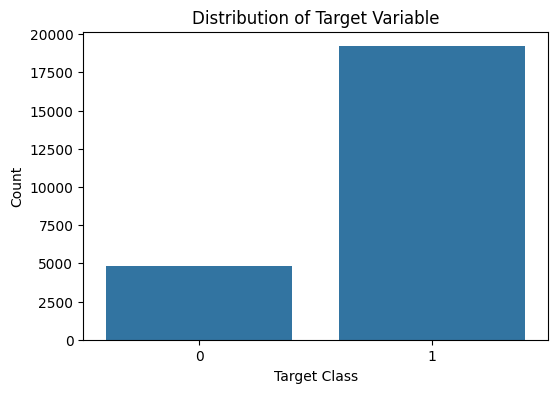

In [4]:
def print_distribution(data):
    plt.figure(figsize=(6, 4))
    sns.countplot(x="target_class", data=data)
    plt.title("Distribution of Target Variable")
    plt.xlabel("Target Class")
    plt.ylabel("Count")
    plt.show()


print_distribution(train_data)

In [5]:
features = train_data.loc[:, "ses_rec":"int_cat24_n"].columns

X_original, y_original = (
    train_data[list(features)],
    train_data["target_class"],
)

In [6]:
def balance_data(X, y, method="smote"):
    if method == "smote":
        sampler = SMOTE()
    elif method == "adasyn":
        sampler = ADASYN()
    else:
        raise ValueError("Method should be either 'smote' or 'adasyn'")

    X_resampled, y_resampled = sampler.fit_resample(X, y)

    return X_resampled, y_resampled

In [7]:
X_resampled, y_resampled = balance_data(X_original, y_original, method="smote")

In [8]:
X = pd.DataFrame(X_resampled, columns=X_original.columns)
y = pd.Series(y_resampled)

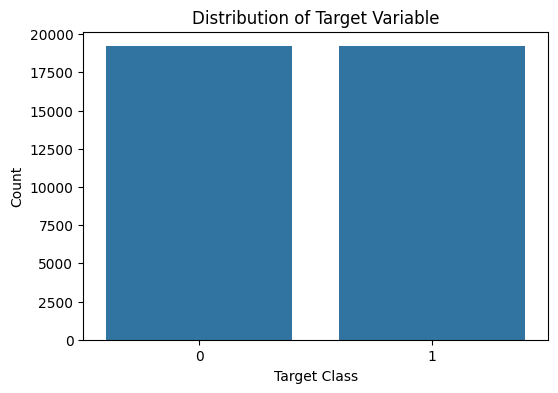

In [9]:
print_distribution(pd.DataFrame(y))

In [10]:
models = [
    LGBMClassifier(n_estimators=200, random_state=42, force_row_wise=True),
    XGBClassifier(n_estimators=200, random_state=42),
    HistGradientBoostingClassifier(random_state=42),
]

model_names = ["LGBM", "XGB", "HGB"]

In [11]:
def cross_val_test(model, dataX, dataY, model_type="classification", n_cv=5):

    # Розбиття для подальшої крос-валідації
    cv = KFold(n_splits=n_cv, shuffle=True, random_state=42)
    # Визначення набору метрик
    if model_type == "regression":
        scorer = {
            "r2": make_scorer(r2_score),
            "mae": make_scorer(mean_absolute_error),
            "mse": make_scorer(mean_squared_error),
            "mape": make_scorer(mean_absolute_percentage_error),
        }
    if model_type == "classification":
        scorer = {"mcc": make_scorer(matthews_corrcoef)}

        pass

    # Оцінка якості моделі на різних наборах даних
    scores = cross_validate(
        model, dataX, dataY, scoring=scorer, cv=cv, return_train_score=True
    )
    return scores

In [12]:
for i in range(0, len(models)):
    model_cv = models[i]
    display(model_cv)
    scores = cross_val_test(model_cv, X, y)

    print(scores.keys())
    # Порівняння метрик тренування-тест
    print(
        "train_mcc, test_mcc: %.3f, %.3f"
        % (np.mean(scores["train_mcc"]), np.mean(scores["test_mcc"]))
    )

,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,200
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


[LightGBM] [Info] Number of positive: 15346, number of negative: 15374
[LightGBM] [Info] Total Bins 6693
[LightGBM] [Info] Number of data points in the train set: 30720, number of used features: 42
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.499544 -> initscore=-0.001823
[LightGBM] [Info] Start training from score -0.001823
[LightGBM] [Info] Number of positive: 15398, number of negative: 15322
[LightGBM] [Info] Total Bins 6707
[LightGBM] [Info] Number of data points in the train set: 30720, number of used features: 42
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.501237 -> initscore=0.004948
[LightGBM] [Info] Start training from score 0.004948
[LightGBM] [Info] Number of positive: 15365, number of negative: 15355
[LightGBM] [Info] Total Bins 6690
[LightGBM] [Info] Number of data points in the train set: 30720, number of used features: 42
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500163 -> initscore=0.000651
[LightGBM] [Info] Start training from score 0.000651
[LightGB

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

dict_keys(['fit_time', 'score_time', 'test_mcc', 'train_mcc'])
train_mcc, test_mcc: 0.989, 0.953


,"loss loss: {'log_loss'}, default='log_loss'The loss function to use in the boosting process.For binary classification problems, 'log_loss' is also known as logistic loss,binomial deviance or binary crossentropy. Internally, the model fits one treeper boosting iteration and uses the logistic sigmoid function (expit) asinverse link function to compute the predicted positive class probability.For multiclass classification problems, 'log_loss' is also known as multinomialdeviance or categorical crossentropy. Internally, the model fits one tree perboosting iteration and per class and uses the softmax function as inverse linkfunction to compute the predicted probabilities of the classes.",'log_loss'
,"learning_rate learning_rate: float, default=0.1The learning rate, also known as *shrinkage*. This is used as amultiplicative factor for the leaves values. Use ``1`` for noshrinkage.",0.1
,"max_iter max_iter: int, default=100The maximum number of iterations of the boosting process, i.e. themaximum number of trees for binary classification. For multiclassclassification, `n_classes` trees per iteration are built.",100
,"max_leaf_nodes max_leaf_nodes: int or None, default=31The maximum number of leaves for each tree. Must be strictly greaterthan 1. If None, there is no maximum limit.",31
,"max_depth max_depth: int or None, default=NoneThe maximum depth of each tree. The depth of a tree is the number ofedges to go from the root to the deepest leaf.Depth isn't constrained by default.",None
,"min_samples_leaf min_samples_leaf: int, default=20The minimum number of samples per leaf. For small datasets with lessthan a few hundred samples, it is recommended to lower this valuesince only very shallow trees would be built.",20
,"l2_regularization l2_regularization: float, default=0The L2 regularization parameter penalizing leaves with small hessians.Use ``0`` for no regularization (default).",0.0
,"max_features max_features: float, default=1.0Proportion of randomly chosen features in each and every node split.This is a form of regularization, smaller values make the trees weakerlearners and might prevent overfitting.If interaction constraints from `interaction_cst` are present, only allowedfeatures are taken into account for the subsampling... versionadded:: 1.4",1.0
,"max_bins max_bins: int, default=255The maximum number of bins to use for non-missing values. Beforetraining, each feature of the input array `X` is binned intointeger-valued bins, which allows for a much faster training stage.Features with a small number of unique values may use less than``max_bins`` bins. In addition to the ``max_bins`` bins, one more binis always reserved for missing values. Must be no larger than 255.",255
,"categorical_features categorical_features: array-like of {bool, int, str} of shape (n_features) or shape (n_categorical_features,), default='from_dtype'Indicates the categorical features.- None : no feature will be considered categorical.- boolean array-like : boolean mask indicating categorical features.- integer array-like : integer indices indicating categorical features.- str array-like: names of categorical features (assuming the training data has feature names).- `""from_dtype""`: dataframe columns with dtype ""category"" are considered to be categorical features. The input must be an object exposing a ``__dataframe__`` method such as pandas or polars DataFrames to use this feature.For each categorical feature, there must be at most `max_bins` uniquecategories. Negative values for categorical features encoded as numericdtypes are treated as missing values. All categorical values areconverted to floating point numbers. This means that categorical valuesof 1.0 and 1 are treated as the same category.Read more in the :ref:`User Guide `... versionadded:: 0.24.. versionchanged:: 1.2 Added support for feature names... versionchanged:: 1.4 Added `""from_dtype""` option... versionchanged:: 1.6 The default value changed from `None` to `""from_dtype""`.",'from_dt

dict_keys(['fit_time', 'score_time', 'test_mcc', 'train_mcc'])
train_mcc, test_mcc: 0.949, 0.938


In [13]:
estimators = list(zip(model_names, models))

In [14]:
final_estimator = XGBClassifier(
    n_estimators=300,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    random_state=42,
)

clf = StackingClassifier(
    estimators=estimators, final_estimator=final_estimator, passthrough=True
)

# clf = StackingClassifier(
#     estimators=estimators, final_estimator=XGBClassifier(), passthrough=True
# )

In [15]:
cross_val_test(clf, X, y)

[LightGBM] [Info] Number of positive: 15346, number of negative: 15374
[LightGBM] [Info] Total Bins 6693
[LightGBM] [Info] Number of data points in the train set: 30720, number of used features: 42
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.499544 -> initscore=-0.001823
[LightGBM] [Info] Start training from score -0.001823
[LightGBM] [Info] Number of positive: 12276, number of negative: 12300
[LightGBM] [Info] Total Bins 6644
[LightGBM] [Info] Number of data points in the train set: 24576, number of used features: 42
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.499512 -> initscore=-0.001953
[LightGBM] [Info] Start training from score -0.001953
[LightGBM] [Info] Number of positive: 12277, number of negative: 12299
[LightGBM] [Info] Total Bins 6651
[LightGBM] [Info] Number of data points in the train set: 24576, number of used features: 42
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.499552 -> initscore=-0.001790
[LightGBM] [Info] Start training from score -0.001790
[Lig

{'fit_time': array([6.2172308 , 5.87901998, 6.24365091, 5.88762951, 5.87794471]),
 'score_time': array([0.07410836, 0.03817558, 0.04326797, 0.05026221, 0.06732798]),
 'test_mcc': array([0.96259532, 0.96055045, 0.95953159, 0.96127513, 0.96115752]),
 'train_mcc': array([0.98629202, 0.98564556, 0.98706112, 0.98488041, 0.98423656])}

In [16]:
model = clf.fit(X_original, y_original)

[LightGBM] [Info] Number of positive: 19200, number of negative: 4800
[LightGBM] [Info] Total Bins 6170
[LightGBM] [Info] Number of data points in the train set: 24000, number of used features: 42
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.800000 -> initscore=1.386294
[LightGBM] [Info] Start training from score 1.386294
[LightGBM] [Info] Number of positive: 15360, number of negative: 3840
[LightGBM] [Info] Total Bins 5925
[LightGBM] [Info] Number of data points in the train set: 19200, number of used features: 42
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.800000 -> initscore=1.386294
[LightGBM] [Info] Start training from score 1.386294
[LightGBM] [Info] Number of positive: 15360, number of negative: 3840
[LightGBM] [Info] Total Bins 5947
[LightGBM] [Info] Number of data points in the train set: 19200, number of used features: 42
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.800000 -> initscore=1.386294
[LightGBM] [Info] Start training from score 1.386294
[LightGBM] [I

In [17]:
X_test = test_data[list(features)]

In [18]:
y_pred = model.predict(X_test)

In [19]:
results = pd.DataFrame(
    {"ID": test_data["Unnamed: 0"], "target": y_pred}
)

In [20]:
results

,ID,target
0,26299,1
1,22255,1
2,24149,1
3,28803,1
4,24862,1
...,...,...
5995,14213,0
5996,16877,1
5997,20207,1
5998,7653,1


In [21]:
results.to_csv("results.csv", index=False)